# PID agent

In [1]:
import sys
sys.path.insert(0, "../")

from math import radians
from random import uniform

from tqdm.notebook import tqdm
import numpy as np
import xarray as xr
import xarray.ufuncs as xrf
import matplotlib.pyplot as plt

from pole.cpp import Environment, PIDAgent

In [2]:
env = Environment(0.500, 0.100, radians(181), radians(180))

In [4]:
agent = PIDAgent(env, 5, 0, 0.3)
env.reset()
env.theta = radians(-5)
env.theta_dot = radians(uniform(-0.1, 0.1))
n_steps = agent.run_episode(1000)
data = agent.get_data()
data

<xarray.Dataset>
Dimensions:     (time: 1000)
Coordinates:
  * time        (time) float64 0.001 0.002 0.003 0.004 ... 0.997 0.998 0.999 1.0
Data variables:
    derivative  (time) float64 0.0 -0.2482 -0.4518 ... -4.945e-08 -4.86e-08
    error       (time) float64 0.08727 0.08702 0.08657 ... 2.821e-09 2.773e-09
    integral    (time) float64 0.0 8.714e-05 0.0001739 ... 0.005463 0.005463
    reward      (time) float64 0.9454 0.9456 0.946 0.9465 ... 1.0 1.0 1.0 1.0
    theta       (time) float64 -0.08702 -0.08657 ... -2.773e-09 -2.725e-09
    theta_dot   (time) float64 0.2482 0.4518 0.6174 ... 4.86e-08 4.776e-08
    torque      (time) float64 0.4363 0.3606 0.2973 ... -7.273e-10 -7.15e-10

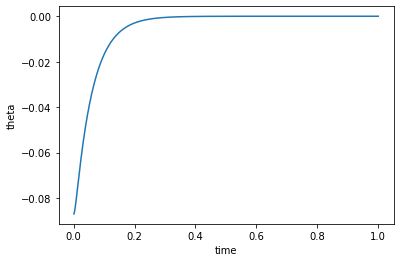

In [5]:
data.theta.plot()